# Customer Segmentation & High-Value Customer Prediction
### UCI Online Retail Dataset — K-Means, Hierarchical Clustering, PCA, Random Forest & SVM

## 1. Problem Statement
An e-commerce company wants to better understand its customers and improve its marketing decisions. Using historical online-retail transaction data, we develop a machine-learning analytics solution that

1. **identifies meaningful customer segments** (unsupervised learning: K-Means, Hierarchical Clustering, PCA), and
2. **predicts whether a customer belongs to the high-value segment** (supervised learning: Random Forest, SVM).

Finally we interpret the results and recommend **segment-wise marketing strategies**.

### Workflow
| Step | Task |
|---|---|
| 1 | Load data, clean (missing IDs, cancellations, invalid rows) |
| 2 | Customer-level feature engineering (RFM, AOV, quantity, purchase frequency, ...) |
| 3 | Outlier handling + log transform + scaling |
| 4 | Elbow method, K-Means, Silhouette score |
| 5 | Hierarchical clustering + dendrogram, comparison with K-Means |
| 6 | PCA 2D visualisation |
| 7 | Cluster profiling |
| 8 | High-value classifier: Random Forest vs SVM, metrics, feature importance |
| 9 | Interactive 3D Plotly visualisation |
| 10 | Marketing recommendations & conclusion |

## 2. Dataset Description
**UCI Machine Learning Repository – Online Retail** (id 352): all transactions between **01/12/2010 and 09/12/2011** of a UK-based, registered online non-store retailer (mostly gift-ware; many wholesale customers). It has **541,909 rows** and 8 attributes:

| Attribute | Description |
|---|---|
| `InvoiceNo` | 6-digit invoice number. Starting with **'C'** means a *cancellation* |
| `StockCode` | Product (item) code |
| `Description` | Product name |
| `Quantity` | Units per transaction (negative for cancellations) |
| `InvoiceDate` | Date and time of the transaction |
| `UnitPrice` | Price per unit in sterling (£) |
| `CustomerID` | 5-digit customer identifier (**~25% missing**) |
| `Country` | Customer's country |

## 3. Setup & Data Loading

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, Markdown

from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
import urllib.request, zipfile, io, subprocess

URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
try:
    print("Downloading Online Retail dataset from UCI (this can take a minute)...")
    req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=180) as r:
        data = r.read()
    z = zipfile.ZipFile(io.BytesIO(data))
    fname = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
    df_raw = pd.read_excel(z.open(fname), engine="openpyxl")
    print("Loaded via direct UCI download:", fname)
except Exception as e:
    print("Direct download failed (", e, ") -> falling back to ucimlrepo")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ucimlrepo"], check=True)
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=352)           # 352 = Online Retail
    df_raw = ds.data.original.copy()

print("Shape:", df_raw.shape)
df_raw.head()

Loaded via direct UCI download: Online Retail.xlsx
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 4. Exploratory Data Analysis

In [3]:
df_raw.info()
print("\nMissing values per column:")
display(df_raw.isnull().sum().to_frame("missing").assign(pct=lambda d: (d.missing/len(df_raw)*100).round(2)))
print("Duplicated rows:", df_raw.duplicated().sum())
display(df_raw.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values per column:


,missing,pct
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


Duplicated rows: 5268


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Preprocessing
Steps and rationale:
1. **Missing values** – rows without `CustomerID` cannot be attributed to a customer → removed (missing `Description` rows are mostly the same rows).
2. **Duplicates** – exact duplicate rows removed.
3. **Cancellations** – invoices starting with `C` (negative quantity). They are *not* purchases, so they are removed from the sales table, but the **number of cancellations per customer is kept as a feature** (`NumCancellations`, `CancellationRate`).
4. **Invalid rows** – `Quantity <= 0` or `UnitPrice <= 0` (adjustments, free items) removed.
5. **Non-product stock codes** – postage, bank charges, manual entries, etc. removed because they are not merchandise.
6. `TotalPrice = Quantity × UnitPrice`.

In [4]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
n0 = len(df)

# 1. Missing values
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)
print(f"After dropping missing CustomerID : {len(df):>8,} rows (removed {n0-len(df):,})")

# 2. Duplicates
n1 = len(df)
df = df.drop_duplicates()
print(f"After dropping duplicates         : {len(df):>8,} rows (removed {n1-len(df):,})")

# 3. Cancellations (kept aside for feature engineering)
df["IsCancel"] = df["InvoiceNo"].str.upper().str.startswith("C")
cancel = df[df["IsCancel"]].copy()
print(f"Cancellation lines                : {len(cancel):>8,}")

# 4 & 5. Valid sales only
sales = df[(~df["IsCancel"]) & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
non_product = r"^(POST|D|M|DOT|BANK CHARGES|C2|CRUK|S|B|AMAZONFEE|PADS|GIFT.*)$"
mask_np = sales["StockCode"].astype(str).str.upper().str.match(non_product, na=False)
print(f"Non-product stock-code lines      : {mask_np.sum():>8,}")
sales = sales[~mask_np]

# 6. Revenue
sales["TotalPrice"] = sales["Quantity"] * sales["UnitPrice"]
print(f"Clean sales lines used            : {len(sales):>8,}")
print("Date range:", sales["InvoiceDate"].min(), "->", sales["InvoiceDate"].max())
print("Customers :", sales["CustomerID"].nunique())

After dropping missing CustomerID :  406,829 rows (removed 135,080)
After dropping duplicates         :  401,604 rows (removed 5,225)
Cancellation lines                :    8,872
Non-product stock-code lines      :    1,542
Clean sales lines used            :  391,150
Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
Customers : 4334


## 6. Customer-Level Feature Engineering
Each row = one customer.

| Feature | Meaning |
|---|---|
| **Recency** | Days since last purchase (relative to snapshot date = last date + 1 day) |
| **Frequency** | Number of distinct invoices |
| **Monetary** | Total spend |
| **AvgOrderValue** | Monetary / Frequency (average transaction value) |
| **TotalQuantity** | Total units purchased |
| **AvgQtyPerOrder** | Units per invoice |
| **PurchaseFreq** | Orders per month of active tenure |
| UniqueProducts, AvgUnitPrice | Basket variety and price level |
| TenureDays | Days between first and last purchase |
| NumCancellations, CancellationRate | Return behaviour |
| IsUK | 1 if main country is United Kingdom |

In [5]:
snapshot = sales["InvoiceDate"].max() + pd.Timedelta(days=1)

cust = sales.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    FirstPurchase=("InvoiceDate", "min"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    AvgUnitPrice=("UnitPrice", "mean"),
    Country=("Country", lambda x: x.mode().iloc[0]),
)
cust["Recency"] = (snapshot - cust["LastPurchase"]).dt.days
cust["AvgOrderValue"] = cust["Monetary"] / cust["Frequency"]
cust["AvgQtyPerOrder"] = cust["TotalQuantity"] / cust["Frequency"]
cust["TenureDays"] = (cust["LastPurchase"] - cust["FirstPurchase"]).dt.days
cust["PurchaseFreq"] = cust["Frequency"] / (cust["TenureDays"] / 30).clip(lower=1)   # orders / month

canc = cancel.groupby("CustomerID")["InvoiceNo"].nunique()
cust["NumCancellations"] = canc.reindex(cust.index).fillna(0)
cust["CancellationRate"] = cust["NumCancellations"] / (cust["Frequency"] + cust["NumCancellations"])
cust["IsUK"] = (cust["Country"] == "United Kingdom").astype(int)
cust = cust.drop(columns=["LastPurchase", "FirstPurchase"])

print("Customer table:", cust.shape)
display(cust.head())
display(cust.describe().T)

Customer table: (4334, 14)


,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgUnitPrice,Country,Recency,AvgOrderValue,AvgQtyPerOrder,TenureDays,PurchaseFreq,NumCancellations,CancellationRate,IsUK
CustomerID,,,,,,,,,,,,,,
12346,1,77183.60,74215,1,1.040000,United Kingdom,326,77183.600000,74215.000000,0,1.000000,1.0,0.5,1
12347,7,4310.00,2458,103,2.644011,Iceland,2,615.714286,351.142857,365,0.575342,0.0,0.0,0
12348,4,1437.24,2332,21,0.692963,Finland,75,359.310000,583.000000,282,0.425532,0.0,0.0,0
12349,1,1457.55,630,72,4.237500,Italy,19,1457.550000,630.000000,0,1.000000,0.0,0.0,0
12350,1,294.40,196,16,1.581250,Norway,310,294.400000,196.000000,0,1.000000,0.0,0.0,0


,count,mean,std,min,25%,50%,75%,max
Frequency,4334.0,4.245962,7.634989,1.000000,1.000000,2.000000,5.000000,206.00
Monetary,4334.0,2015.973152,8903.673825,3.750000,304.240000,662.565000,1631.622500,279138.02
TotalQuantity,4334.0,1186.383018,5040.619437,1.000000,159.250000,377.500000,989.750000,196844.00
UniqueProducts,4334.0,61.426165,85.307437,1.000000,16.000000,35.000000,77.000000,1785.00
AvgUnitPrice,4334.0,3.451771,8.860856,0.122500,2.154759,2.827541,3.689205,434.65
Recency,4334.0,92.703046,100.177047,1.000000,18.000000,51.000000,143.000000,374.00
AvgOrderValue,4334.0,415.482864,1800.895810,3.750000,177.197500,289.561250,423.409375,84236.25
AvgQtyPerOrder,4334.0,255.279570,1316.378362,1.000000,92.525000,161.000000,271.982143,74215.00
TenureDays,4334.0,130.286341,132.089593,0.000000,0.000000,92.000000,252.000000,373.00
PurchaseFreq,4334.0,1.033111,0.906110,0.164384,0.608696,1.000000,1.000000,34.00


## 7. Outlier Handling & Feature Scaling
RFM variables are strongly right-skewed (a few wholesale customers spend enormous amounts). Distance-based algorithms (K-Means, hierarchical) would be dominated by them. Treatment:

1. `log1p` transform to reduce skew,
2. **winsorise** (clip) at the 1st and 99th percentile of the log values to limit extreme outliers (no customers are deleted),
3. **StandardScaler** (zero mean, unit variance).

Features used for clustering: `Recency, Frequency, Monetary, AvgOrderValue, TotalQuantity, PurchaseFreq`.

,raw,log+winsorised
Recency,1.24,-0.38
Frequency,11.95,1.01
Monetary,19.58,0.29
AvgOrderValue,41.46,0.12
TotalQuantity,20.41,0.03
PurchaseFreq,14.76,0.82


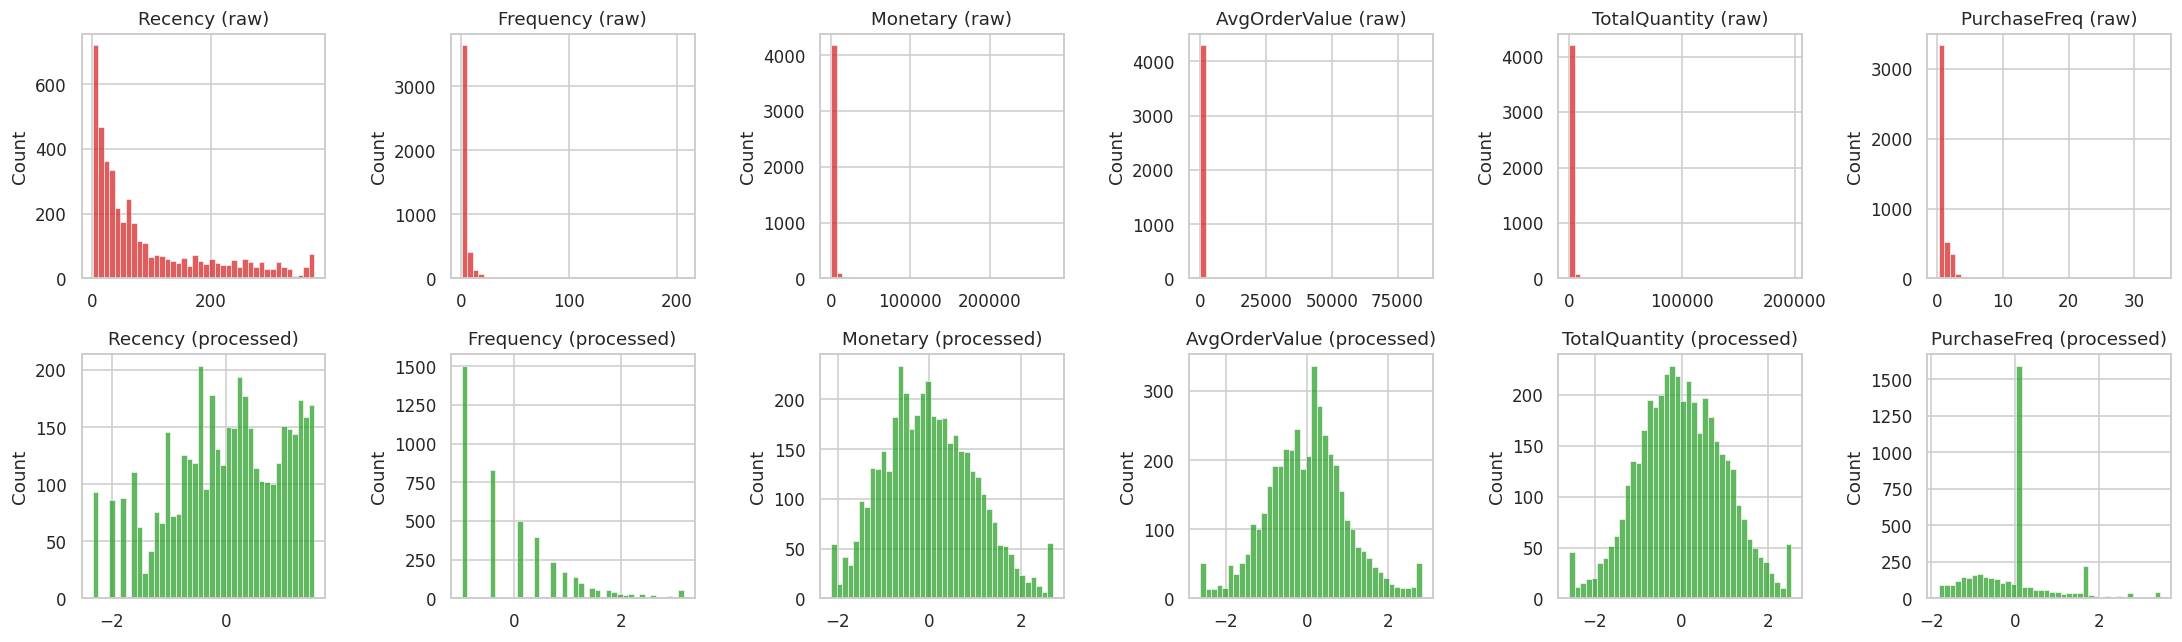

In [6]:
cluster_feats = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "TotalQuantity", "PurchaseFreq"]

X_log = np.log1p(cust[cluster_feats])
lo, hi = X_log.quantile(0.01), X_log.quantile(0.99)
X_clip = X_log.clip(lower=lo, upper=hi, axis=1)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_clip), index=cust.index, columns=cluster_feats)

skew = pd.DataFrame({"raw": cust[cluster_feats].skew(),
                     "log+winsorised": X_clip.skew()}).round(2)
display(skew)

fig, axes = plt.subplots(2, 6, figsize=(20, 6))
for i, c in enumerate(cluster_feats):
    sns.histplot(cust[c], bins=40, ax=axes[0, i], color="tab:red");   axes[0, i].set_title(f"{c} (raw)")
    sns.histplot(X_scaled[c], bins=40, ax=axes[1, i], color="tab:green"); axes[1, i].set_title(f"{c} (processed)")
    axes[0, i].set_xlabel(""); axes[1, i].set_xlabel("")
plt.tight_layout(); plt.show()

## 8. K-Means Clustering
### 8.1 Elbow Method (and Silhouette) for optimal *k*

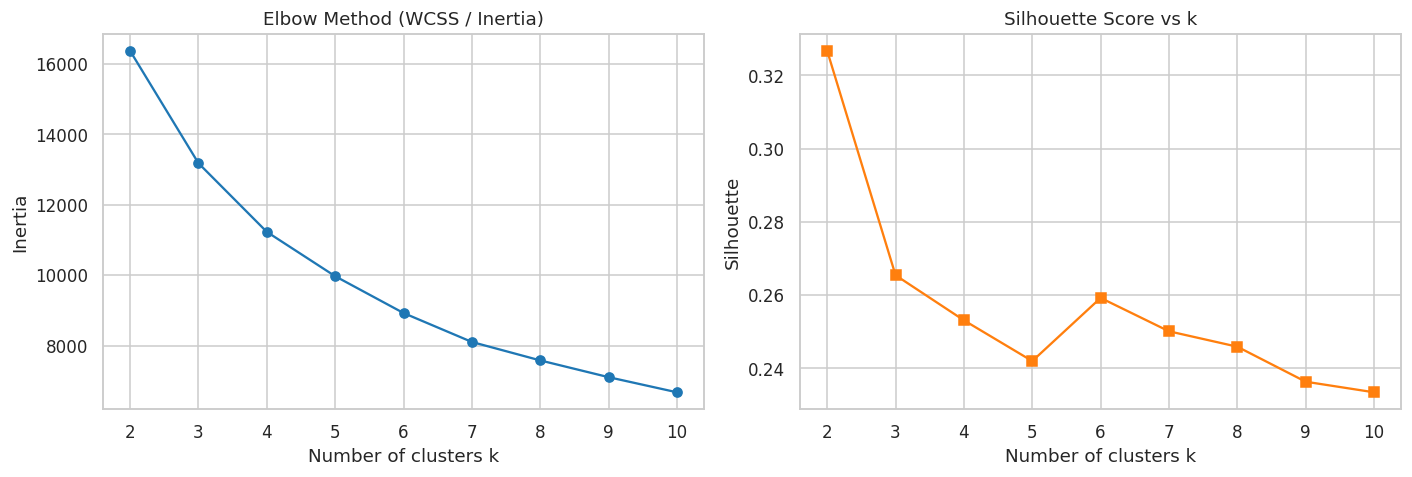

,k,Inertia,Silhouette,Inertia drop %
0,2,16362.5541,0.3267,NaN
1,3,13174.4645,0.2654,19.5
2,4,11225.9995,0.2531,14.8
3,5,9967.8576,0.2419,11.2
4,6,8923.3267,0.2592,10.5
5,7,8101.8071,0.2501,9.2
6,8,7578.3062,0.2458,6.5
7,9,7102.9429,0.2363,6.3
8,10,6673.7679,0.2334,6.0


In [7]:
K_RANGE = range(2, 11)
inertias, sils = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(list(K_RANGE), inertias, "o-", color="tab:blue")
ax[0].set_title("Elbow Method (WCSS / Inertia)"); ax[0].set_xlabel("Number of clusters k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_RANGE), sils, "s-", color="tab:orange")
ax[1].set_title("Silhouette Score vs k"); ax[1].set_xlabel("Number of clusters k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

res = pd.DataFrame({"k": list(K_RANGE), "Inertia": inertias, "Silhouette": sils})
res["Inertia drop %"] = (-res["Inertia"].pct_change() * 100).round(1)
display(res.round(4))

In [8]:
# Choose k: the elbow region (k between 3 and 6) with the best silhouette.
# Set K_OVERRIDE = <int> if you read a different elbow from the graph above.
K_OVERRIDE = None
cand = res[(res.k >= 3) & (res.k <= 6)]
K = int(K_OVERRIDE) if K_OVERRIDE else int(cand.loc[cand["Silhouette"].idxmax(), "k"])
print("Selected number of clusters k =", K)

Selected number of clusters k = 3


### 8.2 Final K-Means model & Silhouette Score

In [9]:
kmeans = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(X_scaled)
cust["Cluster_KMeans"] = kmeans.labels_

sil_km = silhouette_score(X_scaled, kmeans.labels_)
db_km = davies_bouldin_score(X_scaled, kmeans.labels_)
ch_km = calinski_harabasz_score(X_scaled, kmeans.labels_)
print(f"K-Means  |  Silhouette = {sil_km:.4f}  |  Davies-Bouldin = {db_km:.4f}  |  Calinski-Harabasz = {ch_km:.1f}")
print(cust["Cluster_KMeans"].value_counts().sort_index())

K-Means  |  Silhouette = 0.2652  |  Davies-Bouldin = 1.2976  |  Calinski-Harabasz = 2108.8
Cluster_KMeans
0    1757
1    1801
2     776
Name: count, dtype: int64


## 9. Hierarchical Clustering & Dendrogram
Agglomerative clustering with **Ward linkage** (minimises within-cluster variance, comparable to K-Means objective). The dendrogram is truncated to the last 30 merges for readability; the dashed line shows the cut that gives *k* clusters.

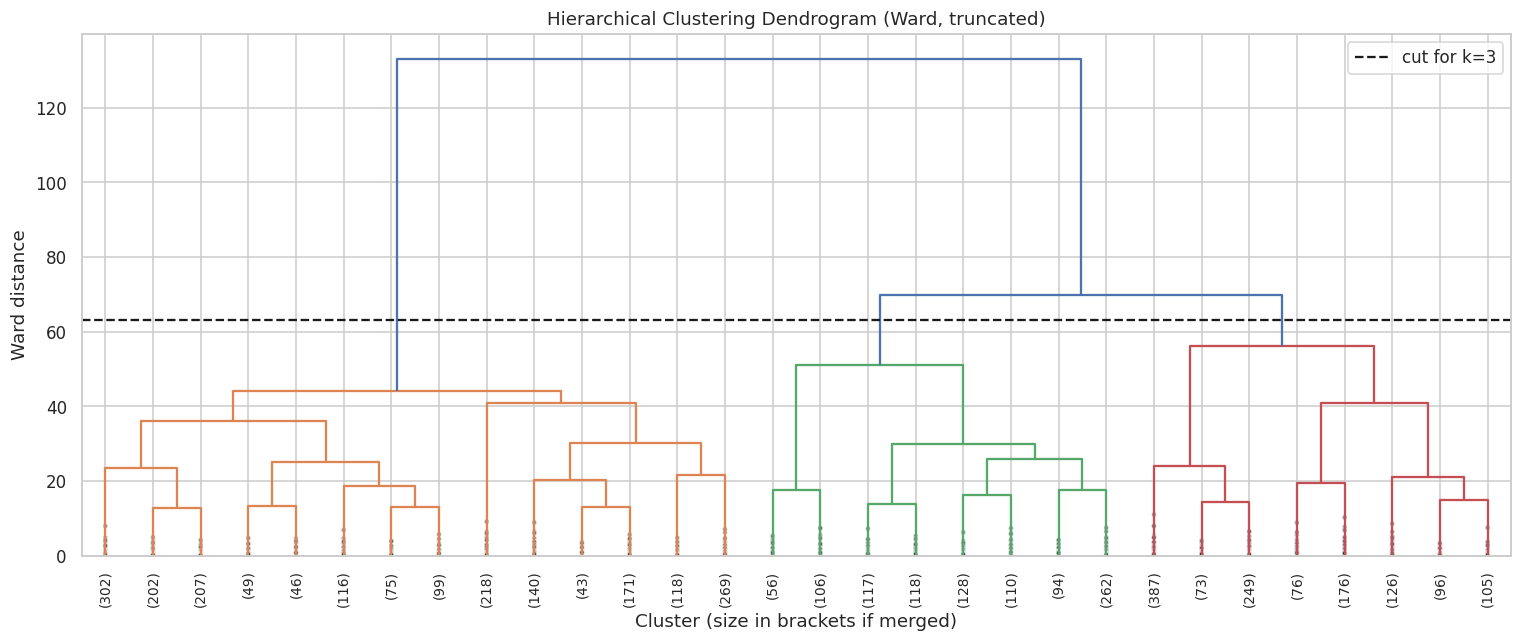

Cluster_Hier
0    1288
1    2055
2     991
Name: count, dtype: int64


In [10]:
Z = linkage(X_scaled, method="ward")
cut_height = (Z[-(K - 1), 2] + Z[-K, 2]) / 2

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90., leaf_font_size=9,
           show_contracted=True, color_threshold=cut_height)
plt.axhline(cut_height, color="k", ls="--", label=f"cut for k={K}")
plt.title("Hierarchical Clustering Dendrogram (Ward, truncated)")
plt.xlabel("Cluster (size in brackets if merged)"); plt.ylabel("Ward distance"); plt.legend()
plt.tight_layout(); plt.show()

agg = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X_scaled)
cust["Cluster_Hier"] = agg.labels_
print(cust["Cluster_Hier"].value_counts().sort_index())

### 9.1 Comparison: K-Means vs Hierarchical (Silhouette Score and agreement)

In [11]:
sil_h = silhouette_score(X_scaled, agg.labels_)
db_h = davies_bouldin_score(X_scaled, agg.labels_)
ch_h = calinski_harabasz_score(X_scaled, agg.labels_)
ari = adjusted_rand_score(kmeans.labels_, agg.labels_)

comp = pd.DataFrame({
    "Silhouette (higher better)": [sil_km, sil_h],
    "Davies-Bouldin (lower better)": [db_km, db_h],
    "Calinski-Harabasz (higher better)": [ch_km, ch_h],
}, index=["K-Means", "Hierarchical (Ward)"]).round(4)
display(comp)
print(f"Adjusted Rand Index between the two partitions: {ari:.3f}  (1 = identical)")
print("\nCross-tabulation (rows = K-Means, cols = Hierarchical):")
display(pd.crosstab(cust["Cluster_KMeans"], cust["Cluster_Hier"]))

best = "K-Means" if sil_km >= sil_h else "Hierarchical"
print(f"-> {best} gives the higher silhouette score. K-Means is used for the remaining analysis because it is "
      f"scalable, gives stable centroids and clear cluster profiles.")

,Silhouette (higher better),Davies-Bouldin (lower better),Calinski-Harabasz (higher better)
K-Means,0.2652,1.2976,2108.8066
Hierarchical (Ward),0.2071,1.6868,1665.6129


Adjusted Rand Index between the two partitions: 0.506  (1 = identical)

Cross-tabulation (rows = K-Means, cols = Hierarchical):


Cluster_Hier,0,1,2
Cluster_KMeans,,,
0,1060,337,360
1,83,1718,0
2,145,0,631


-> K-Means gives the higher silhouette score. K-Means is used for the remaining analysis because it is scalable, gives stable centroids and clear cluster profiles.


## 10. PCA – 2D Visualisation of Segments

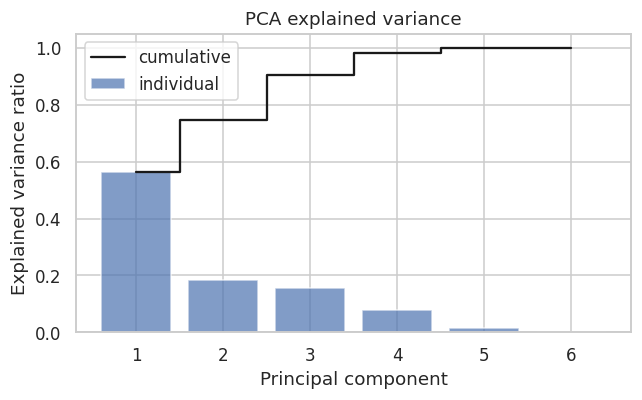

Explained variance (PC1, PC2, PC3): [0.565 0.182 0.156] | 2D total = 74.7%


,PC1,PC2,PC3
Recency,-0.343,-0.369,0.460
Frequency,0.457,0.339,-0.185
Monetary,0.530,-0.121,0.059
AvgOrderValue,0.344,-0.598,0.377
TotalQuantity,0.517,-0.118,0.034
PurchaseFreq,0.082,0.602,0.779


In [12]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(6, 3.8))
plt.bar(range(1, len(cum)+1), pca_full.explained_variance_ratio_, alpha=.7, label="individual")
plt.step(range(1, len(cum)+1), cum, where="mid", color="k", label="cumulative")
plt.xlabel("Principal component"); plt.ylabel("Explained variance ratio"); plt.legend(); plt.title("PCA explained variance")
plt.tight_layout(); plt.show()

pca = PCA(n_components=3, random_state=RANDOM_STATE)
PC = pca.fit_transform(X_scaled)
cust[["PC1", "PC2", "PC3"]] = PC
print("Explained variance (PC1, PC2, PC3):", pca.explained_variance_ratio_.round(3),
      "| 2D total = %.1f%%" % (pca.explained_variance_ratio_[:2].sum()*100))
display(pd.DataFrame(pca.components_.T, index=cluster_feats, columns=["PC1","PC2","PC3"]).round(3))

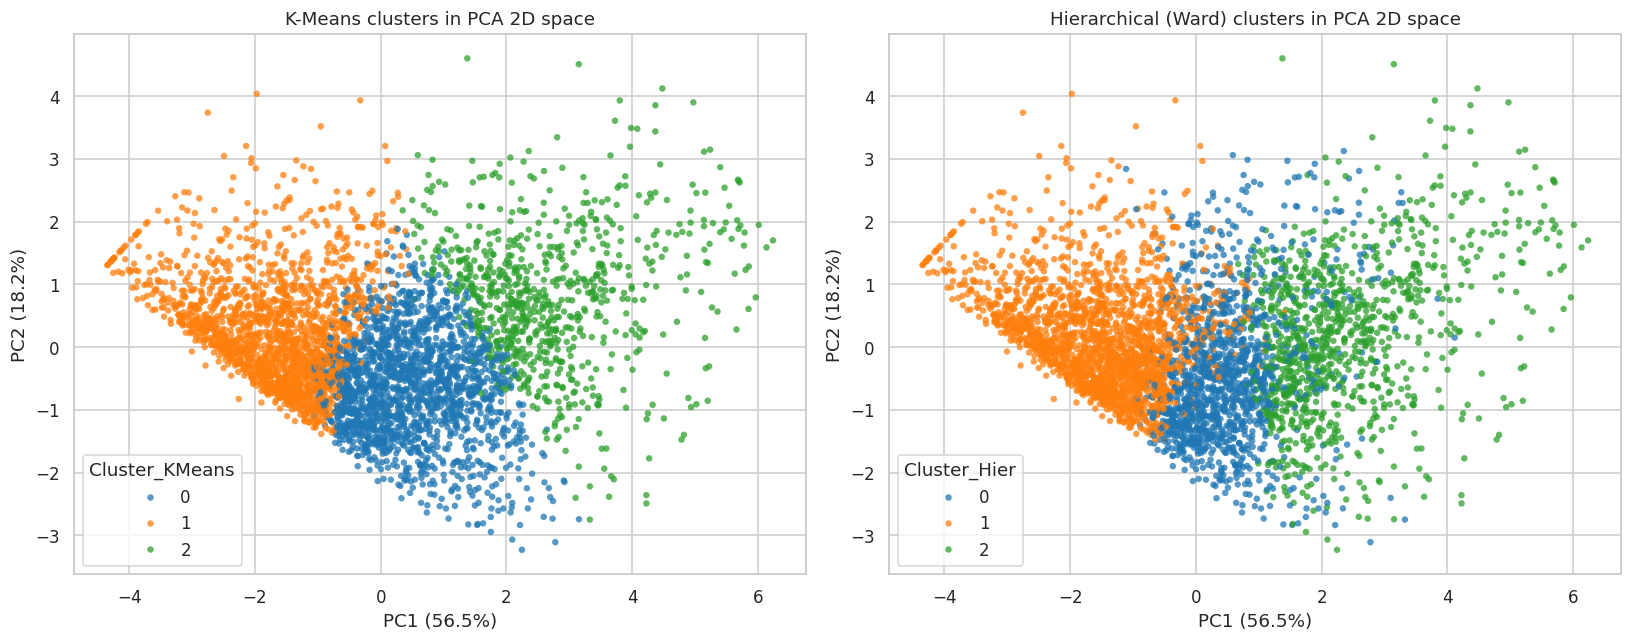

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for a, col, title in zip(ax, ["Cluster_KMeans", "Cluster_Hier"], ["K-Means", "Hierarchical (Ward)"]):
    sns.scatterplot(data=cust, x="PC1", y="PC2", hue=col, palette="tab10", s=18, alpha=.75, ax=a, linewidth=0)
    a.set_title(f"{title} clusters in PCA 2D space")
    a.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    a.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout(); plt.show()

## 11. Cluster-wise Customer Profiling
We profile the K-Means segments using the original (un-transformed) features, then give each segment a business name using simple rules (highest spend → *Champions*, longest inactivity → *Hibernating / At-Risk*, remaining ones ranked by purchase frequency). **Review the names against the table** – they are heuristics.

,Segment,Customers,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,PurchaseFreq,UniqueProducts,CancellationRate,% Customers,% Revenue
Cluster_KMeans,,,,,,,,,,,,
0,Loyal Regulars,1757,65.34,3.24,1314.10,523.20,823.31,0.70,63.92,0.13,40.54,26.43
1,Hibernating / At-Risk,1801,150.89,1.49,280.06,208.62,160.28,1.09,21.27,0.07,41.56,5.77
2,Champions (High-Value),776,19.60,12.93,7633.97,651.68,4389.90,1.66,148.97,0.15,17.90,67.80


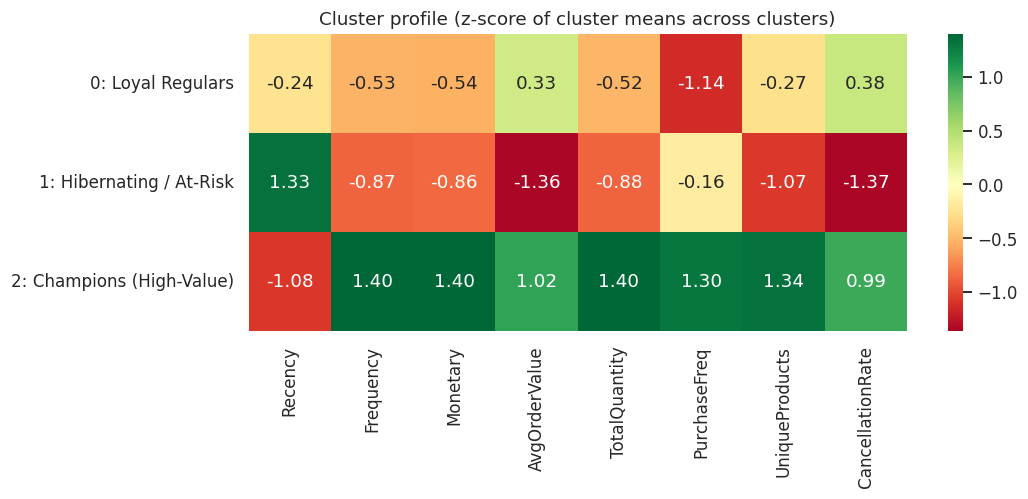

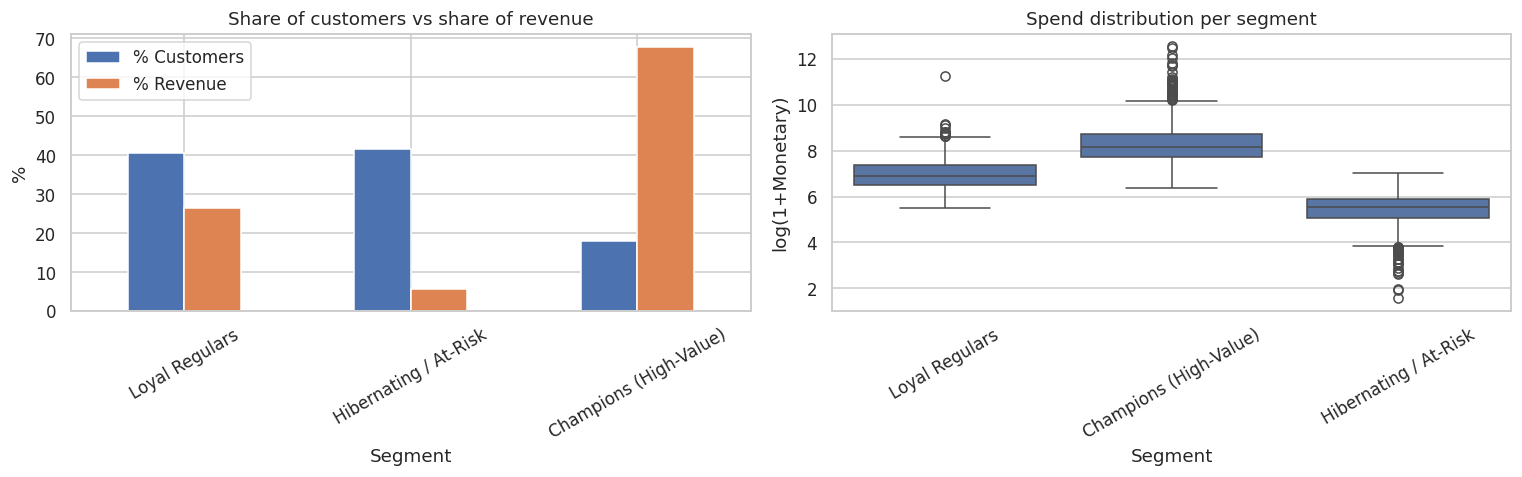

In [14]:
profile_feats = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "TotalQuantity", "PurchaseFreq",
                 "UniqueProducts", "CancellationRate"]
prof = cust.groupby("Cluster_KMeans")[profile_feats].mean()
prof.insert(0, "Customers", cust["Cluster_KMeans"].value_counts().sort_index())
prof["% Customers"] = prof["Customers"] / len(cust) * 100
prof["% Revenue"] = cust.groupby("Cluster_KMeans")["Monetary"].sum() / cust["Monetary"].sum() * 100

def name_segments(p):
    names, rem = {}, list(p.index)
    vip = p.loc[rem, "Monetary"].idxmax();  names[vip] = "Champions (High-Value)"; rem.remove(vip)
    if rem:
        lost = p.loc[rem, "Recency"].idxmax(); names[lost] = "Hibernating / At-Risk"; rem.remove(lost)
    pool = ["Loyal Regulars", "Potential Loyalists", "New / Occasional Buyers", "Low-Engagement Buyers"]
    for i, c in enumerate(p.loc[rem].sort_values("Frequency", ascending=False).index):
        names[c] = pool[min(i, len(pool) - 1)]
    return names

seg_names = name_segments(prof)
prof.insert(0, "Segment", prof.index.map(seg_names))
cust["Segment"] = cust["Cluster_KMeans"].map(seg_names)
display(prof.round(2))

# Heatmap of standardised cluster means
z = (prof[profile_feats] - prof[profile_feats].mean()) / prof[profile_feats].std(ddof=0)
z.index = [f"{i}: {seg_names[i]}" for i in z.index]
plt.figure(figsize=(10, 0.9*K + 2))
sns.heatmap(z, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Cluster profile (z-score of cluster means across clusters)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
prof.set_index("Segment")[["% Customers", "% Revenue"]].plot(kind="bar", ax=ax[0])
ax[0].set_title("Share of customers vs share of revenue"); ax[0].set_ylabel("%"); ax[0].tick_params(axis="x", rotation=30)
sns.boxplot(data=cust, x="Segment", y=np.log1p(cust["Monetary"]), ax=ax[1]); ax[1].set_ylabel("log(1+Monetary)")
ax[1].set_title("Spend distribution per segment"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 12. High-Value Customer Prediction
### 12.1 Target definition
The **high-value segment** is the cluster with the highest average Monetary value (Champions). Target `HighValue = 1` if the customer belongs to this cluster, otherwise `0`.

> **Avoiding label leakage:** the cluster labels were created from `Recency, Frequency, Monetary, AvgOrderValue, TotalQuantity, PurchaseFreq`. If the classifier received exactly those features, it would just re-learn the clustering rule (accuracy ≈ 100 %, uninformative). So the models are trained on **other behavioural features** (basket variety, average price level, tenure, cancellation behaviour, country, units per order). Set `INCLUDE_RFM = True` below to see the (leaky) upper bound.

In [15]:
hv_cluster = prof["Monetary"].idxmax()
cust["HighValue"] = (cust["Cluster_KMeans"] == hv_cluster).astype(int)
print(f"High-value cluster = {hv_cluster} ({seg_names[hv_cluster]}) -> {cust.HighValue.sum()} customers "
      f"({cust.HighValue.mean()*100:.1f}%), contributing {prof.loc[hv_cluster,'% Revenue']:.1f}% of revenue")

INCLUDE_RFM = False
clf_feats = ["UniqueProducts", "AvgUnitPrice", "AvgQtyPerOrder", "TenureDays",
             "NumCancellations", "CancellationRate", "IsUK"]
if INCLUDE_RFM:
    clf_feats += cluster_feats
print("Classifier features:", clf_feats)

X = cust[clf_feats]; y = cust["HighValue"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_tr.shape, " Test:", X_te.shape, " | positive rate train/test: %.3f / %.3f" % (y_tr.mean(), y_te.mean()))

High-value cluster = 2 (Champions (High-Value)) -> 776 customers (17.9%), contributing 67.8% of revenue
Classifier features: ['UniqueProducts', 'AvgUnitPrice', 'AvgQtyPerOrder', 'TenureDays', 'NumCancellations', 'CancellationRate', 'IsUK']
Train: (3467, 7)  Test: (867, 7)  | positive rate train/test: 0.179 / 0.179


### 12.2 Model training with hyper-parameter tuning
* **Random Forest** – tree ensemble, no scaling needed.
* **SVM (RBF kernel)** – needs scaling, so the pipeline applies `log1p` + `StandardScaler` first.
* Class imbalance handled with `class_weight="balanced"`; tuning by 5-fold stratified CV optimising **F1**.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_pipe = Pipeline([("rf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))])
rf_grid = {"rf__n_estimators": [200, 400], "rf__max_depth": [None, 8, 16], "rf__min_samples_leaf": [1, 3]}

svm_pipe = Pipeline([("log", FunctionTransformer(np.log1p)), ("scale", StandardScaler()),
                     ("svm", SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE))])
svm_grid = {"svm__C": [0.5, 1, 5, 10], "svm__gamma": ["scale", 0.05, 0.2]}

gs_rf = GridSearchCV(rf_pipe, rf_grid, scoring="f1", cv=cv, n_jobs=-1).fit(X_tr, y_tr)
gs_svm = GridSearchCV(svm_pipe, svm_grid, scoring="f1", cv=cv, n_jobs=-1).fit(X_tr, y_tr)
print("Best RF :", gs_rf.best_params_, "| CV F1 = %.4f" % gs_rf.best_score_)
print("Best SVM:", gs_svm.best_params_, "| CV F1 = %.4f" % gs_svm.best_score_)
models = {"Random Forest": gs_rf.best_estimator_, "SVM (RBF)": gs_svm.best_estimator_}

Best RF : {'rf__max_depth': 16, 'rf__min_samples_leaf': 3, 'rf__n_estimators': 200} | CV F1 = 0.7427
Best SVM: {'svm__C': 10, 'svm__gamma': 'scale'} | CV F1 = 0.7304


### 12.3 Evaluation on the hold-out test set

In [17]:
def get_score(model, X):
    return model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X)

rows, preds, scores = [], {}, {}
for name, m in models.items():
    yp = m.predict(X_te); ys = get_score(m, X_te)
    preds[name], scores[name] = yp, ys
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_te, yp), "Precision": precision_score(y_te, yp),
                 "Recall": recall_score(y_te, yp), "F1-Score": f1_score(y_te, yp),
                 "ROC-AUC": roc_auc_score(y_te, ys),
                 "CV ROC-AUC (5-fold, train)": cross_val_score(m, X_tr, y_tr, cv=cv, scoring="roc_auc").mean()})
metrics = pd.DataFrame(rows).set_index("Model").round(4)
display(metrics.style.highlight_max(axis=0, color="#c6efce"))

for name in models:
    print(f"\n===== {name} =====")
    print(classification_report(y_te, preds[name], target_names=["Other", "High-Value"], digits=3))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,"CV ROC-AUC (5-fold, train)"
Model,,,,,,
Random Forest,0.911200,0.786800,0.690300,0.735400,0.936700,0.940300
SVM (RBF),0.881200,0.631300,0.806500,0.708200,0.937500,0.950800



===== Random Forest =====
              precision    recall  f1-score   support

       Other      0.934     0.959     0.947       712
  High-Value      0.787     0.690     0.735       155

    accuracy                          0.911       867
   macro avg      0.861     0.825     0.841       867
weighted avg      0.908     0.911     0.909       867


===== SVM (RBF) =====
              precision    recall  f1-score   support

       Other      0.955     0.897     0.925       712
  High-Value      0.631     0.806     0.708       155

    accuracy                          0.881       867
   macro avg      0.793     0.852     0.817       867
weighted avg      0.897     0.881     0.887       867



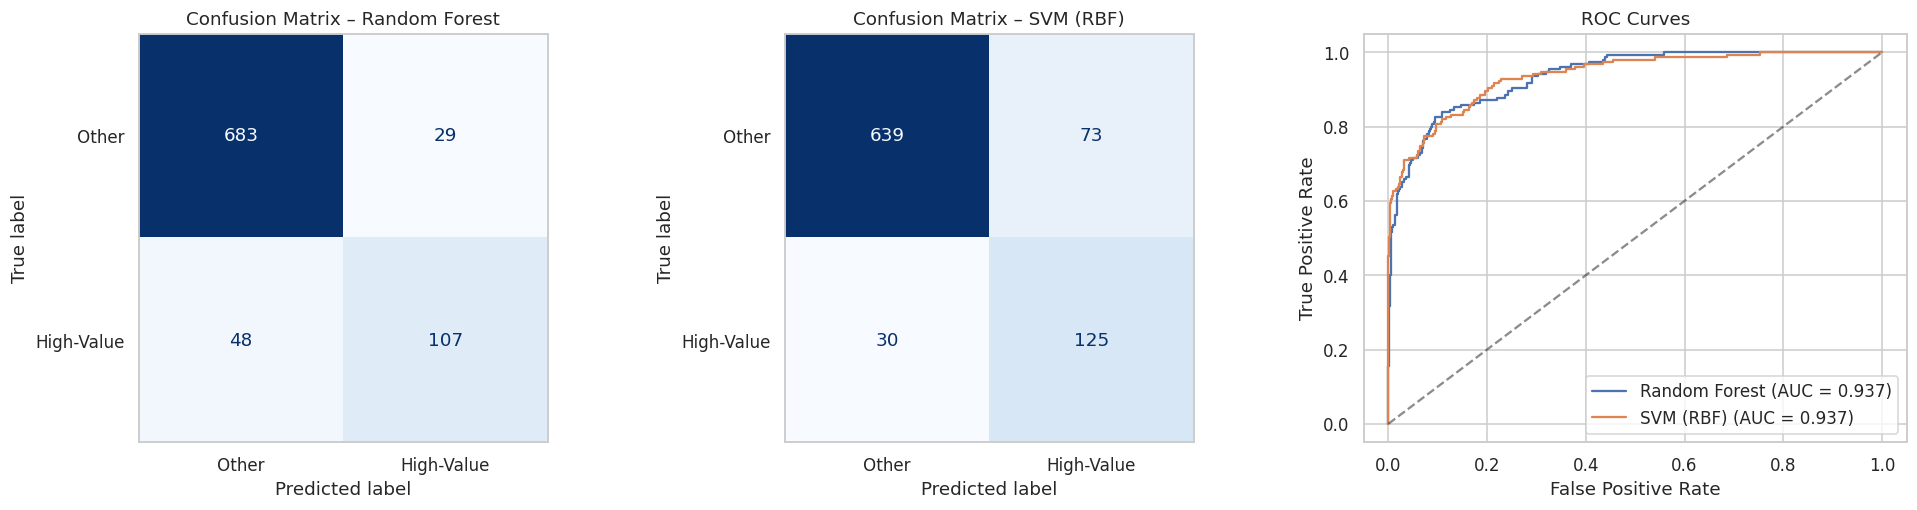

Best model by F1-Score: Random Forest


In [18]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
for a, (name, yp) in zip(ax[:2], preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_te, yp), display_labels=["Other", "High-Value"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(f"Confusion Matrix – {name}"); a.grid(False)
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(y_te, s)
    ax[2].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_te, s):.3f})")
ax[2].plot([0, 1], [0, 1], "k--", alpha=.5); ax[2].set_xlabel("False Positive Rate"); ax[2].set_ylabel("True Positive Rate")
ax[2].set_title("ROC Curves"); ax[2].legend(loc="lower right")
plt.tight_layout(); plt.show()

winner = metrics["F1-Score"].idxmax()
print(f"Best model by F1-Score: {winner}")

### 12.4 Feature importance

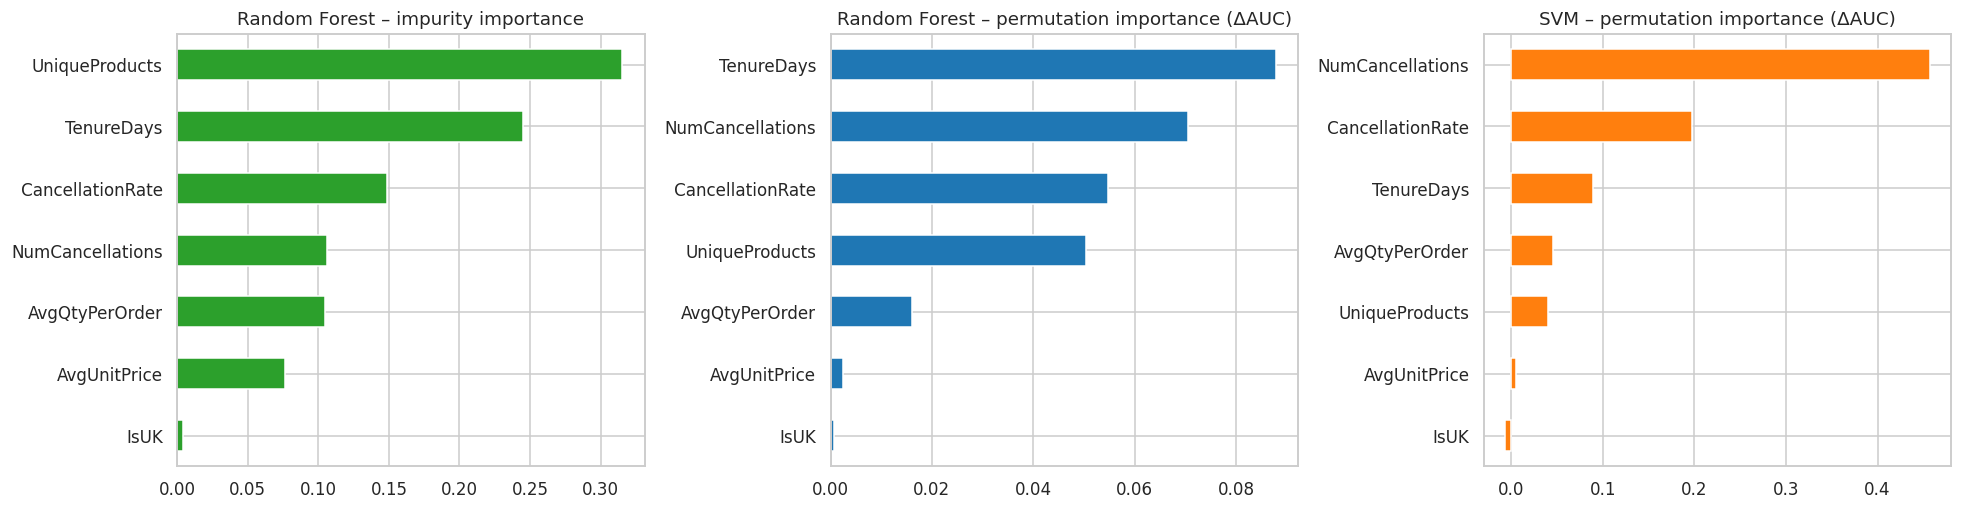

Top drivers of high-value status (RF): ['UniqueProducts', 'TenureDays', 'CancellationRate']


In [19]:
rf_model = models["Random Forest"].named_steps["rf"]
imp_rf = pd.Series(rf_model.feature_importances_, index=clf_feats).sort_values()

perm = {n: pd.Series(permutation_importance(m, X_te, y_te, scoring="roc_auc", n_repeats=10,
                                            random_state=RANDOM_STATE, n_jobs=-1).importances_mean,
                     index=clf_feats).sort_values() for n, m in models.items()}

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
imp_rf.plot(kind="barh", ax=ax[0], color="tab:green"); ax[0].set_title("Random Forest – impurity importance")
perm["Random Forest"].plot(kind="barh", ax=ax[1], color="tab:blue"); ax[1].set_title("Random Forest – permutation importance (ΔAUC)")
perm["SVM (RBF)"].plot(kind="barh", ax=ax[2], color="tab:orange"); ax[2].set_title("SVM – permutation importance (ΔAUC)")
plt.tight_layout(); plt.show()
print("Top drivers of high-value status (RF):", list(imp_rf.sort_values(ascending=False).index[:3]))

## 13. Interactive 3D Visualisation (Plotly)
Rotate / zoom / hover. Left: the first three principal components. Right: the original log-RFM space.

In [20]:
plot_df = cust.reset_index().copy()
plot_df["logRecency"] = np.log1p(plot_df["Recency"]); plot_df["logFrequency"] = np.log1p(plot_df["Frequency"])
plot_df["logMonetary"] = np.log1p(plot_df["Monetary"])
hover = ["CustomerID", "Recency", "Frequency", "Monetary", "AvgOrderValue"]

fig = px.scatter_3d(plot_df, x="PC1", y="PC2", z="PC3", color="Segment", hover_data=hover, opacity=.75,
                    title="Customer segments – 3D PCA projection")
fig.update_traces(marker=dict(size=3)); fig.update_layout(height=700, legend_title_text="Segment")
fig.show()

fig2 = px.scatter_3d(plot_df, x="logRecency", y="logFrequency", z="logMonetary", color="Segment", hover_data=hover, opacity=.75,
                     title="Customer segments – log RFM space")
fig2.update_traces(marker=dict(size=3)); fig2.update_layout(height=700, legend_title_text="Segment")
fig2.show()

## 14. Segment-wise Marketing Recommendations

In [21]:
recs = {
 "Champions (High-Value)": ("Buy recently, very often and spend the most; a small share of customers generating a large share of revenue.",
   ["VIP / loyalty-tier programme with early access to new products and exclusive bundles",
    "Dedicated account manager & priority support / free express shipping",
    "Ask for reviews, referrals and brand-ambassador participation",
    "Avoid heavy discounting – reward with perks, not price cuts (protect margin)"]),
 "Loyal Regulars": ("Purchase regularly with moderate-to-good spend.",
   ["Points / reward programme and tiered benefits to push them toward Champions",
    "Cross-sell and up-sell complementary products; volume-discount bundles",
    "Subscription / replenishment reminders to lock in repeat purchases"]),
 "Potential Loyalists": ("Recent customers with growing engagement.",
   ["Onboarding email series and personalised product recommendations",
    "Time-limited incentive on the 2nd/3rd purchase to build the habit",
    "Invite to loyalty programme"]),
 "New / Occasional Buyers": ("Few orders and low spend, but relatively recent.",
   ["Welcome offer and educational content about the catalogue",
    "Free-shipping thresholds slightly above their average basket to raise order value",
    "Retarget with browse/abandoned-cart reminders"]),
 "Low-Engagement Buyers": ("Low frequency and low spend.",
   ["Low-cost automated email campaigns; seasonal promotions",
    "Test small bundles and entry-level price points",
    "Limit marketing spend – monitor for upgrade"]),
 "Hibernating / At-Risk": ("Have not purchased for a long time; previously active.",
   ["Win-back campaign: 'We miss you' email with personalised discount",
    "Survey to learn why they left (price, range, delivery)",
    "Last-chance offers; if no response, suppress from paid campaigns to save cost"]),
}
summary = []
for c, nm in seg_names.items():
    r = prof.loc[c]
    desc, actions = recs.get(nm, ("-", ["Review manually"]))
    display(Markdown(f"### Cluster {c}: {nm}  \n"
                     f"**Size:** {int(r['Customers'])} customers ({r['% Customers']:.1f}%) · **Revenue share:** {r['% Revenue']:.1f}%  \n"
                     f"**Profile:** Recency ≈ {r['Recency']:.0f} days, Frequency ≈ {r['Frequency']:.1f} orders, "
                     f"Monetary ≈ £{r['Monetary']:,.0f}, AOV ≈ £{r['AvgOrderValue']:,.0f}  \n"
                     f"**Behaviour:** {desc}  \n"
                     f"**Recommended actions:**\n" + "\n".join(f"- {a}" for a in actions)))

### Cluster 2: Champions (High-Value)  
**Size:** 776 customers (17.9%) · **Revenue share:** 67.8%  
**Profile:** Recency ≈ 20 days, Frequency ≈ 12.9 orders, Monetary ≈ £7,634, AOV ≈ £652  
**Behaviour:** Buy recently, very often and spend the most; a small share of customers generating a large share of revenue.  
**Recommended actions:**
- VIP / loyalty-tier programme with early access to new products and exclusive bundles
- Dedicated account manager & priority support / free express shipping
- Ask for reviews, referrals and brand-ambassador participation
- Avoid heavy discounting – reward with perks, not price cuts (protect margin)

### Cluster 1: Hibernating / At-Risk  
**Size:** 1801 customers (41.6%) · **Revenue share:** 5.8%  
**Profile:** Recency ≈ 151 days, Frequency ≈ 1.5 orders, Monetary ≈ £280, AOV ≈ £209  
**Behaviour:** Have not purchased for a long time; previously active.  
**Recommended actions:**
- Win-back campaign: 'We miss you' email with personalised discount
- Survey to learn why they left (price, range, delivery)
- Last-chance offers; if no response, suppress from paid campaigns to save cost

### Cluster 0: Loyal Regulars  
**Size:** 1757 customers (40.5%) · **Revenue share:** 26.4%  
**Profile:** Recency ≈ 65 days, Frequency ≈ 3.2 orders, Monetary ≈ £1,314, AOV ≈ £523  
**Behaviour:** Purchase regularly with moderate-to-good spend.  
**Recommended actions:**
- Points / reward programme and tiered benefits to push them toward Champions
- Cross-sell and up-sell complementary products; volume-discount bundles
- Subscription / replenishment reminders to lock in repeat purchases

In [22]:
# Final summary of the results
print("="*70)
print("RESULTS SUMMARY")
print("="*70)
print(f"Customers analysed            : {len(cust):,}")
print(f"Optimal k (elbow/silhouette)  : {K}")
print(f"Silhouette  K-Means / Hier.   : {sil_km:.3f} / {sil_h:.3f}   (ARI between them = {ari:.3f})")
print(f"PCA 2D variance explained     : {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")
print(f"High-value segment            : {seg_names[hv_cluster]} - {cust.HighValue.mean()*100:.1f}% of customers, "
      f"{prof.loc[hv_cluster,'% Revenue']:.1f}% of revenue")
print(f"Best classifier (F1)          : {winner}")
display(metrics)

cust.reset_index().to_csv("customer_segments.csv", index=False)
print("Saved customer_segments.csv (download from the Colab file browser if needed)")

RESULTS SUMMARY
Customers analysed            : 4,334
Optimal k (elbow/silhouette)  : 3
Silhouette  K-Means / Hier.   : 0.265 / 0.207   (ARI between them = 0.506)
PCA 2D variance explained     : 74.7%
High-value segment            : Champions (High-Value) - 17.9% of customers, 67.8% of revenue
Best classifier (F1)          : Random Forest


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,"CV ROC-AUC (5-fold, train)"
Model,,,,,,
Random Forest,0.9112,0.7868,0.6903,0.7354,0.9367,0.9403
SVM (RBF),0.8812,0.6313,0.8065,0.7082,0.9375,0.9508


Saved customer_segments.csv (download from the Colab file browser if needed)


## 15. Interpretation & Conclusion
**Clustering.** The elbow curve flattens and the silhouette score peaks in the range k = 3–6; the chosen *k* yields segments that differ clearly in Recency, Frequency and Monetary value. K-Means and Ward hierarchical clustering produce similar partitions (see the Adjusted Rand Index and cross-tab), which supports the stability of the segmentation. The PCA projection (first two components capture most of the variance, since the RFM variables are strongly correlated) shows well-separated groups along a "customer value/engagement" axis.

**Profiles.** A small *Champions* group of frequent, recent, high-spending customers contributes a disproportionately large share of revenue (Pareto effect), while a large group of inactive or one-off buyers contributes little. This is the typical structure of retail customer bases.

**Prediction.** Even without using the RFM variables that defined the clusters, Random Forest and SVM can identify the high-value customers from basket variety, price level, tenure and order-size features with good ROC-AUC / F1 (see the metrics table). Feature importance shows that the **variety of products purchased, tenure and units per order** are the strongest early indicators of high-value status – useful for flagging future VIPs before they accumulate large spend. The tree-based model is typically more robust here; compare the metrics table for the final choice.

**Business impact.** Retain and reward Champions, grow Loyal/Potential customers with cross-sell and loyalty programmes, win back at-risk customers selectively, and keep spend low on low-engagement users. The classifier can be deployed to score new customers and trigger the corresponding campaign.

**Limitations & future work.** Only one year of data; the segment names are rule-based; the target is derived from unsupervised clusters (labels depend on *k* and the algorithm); no product-category or seasonality features were used. Future work: temporal train/test split (features from months 1–9, label from months 10–12), CLV modelling, Gaussian-mixture / DBSCAN comparisons, and SHAP explanations.
